<a href="https://colab.research.google.com/github/gokul171EK/AI_ML_Specific_Models/blob/main/k-means%20clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Iris.csv to Iris.csv
DATASET LOADED SUCCESSFULLY
Rows    : 150
Columns : 6


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Features used:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


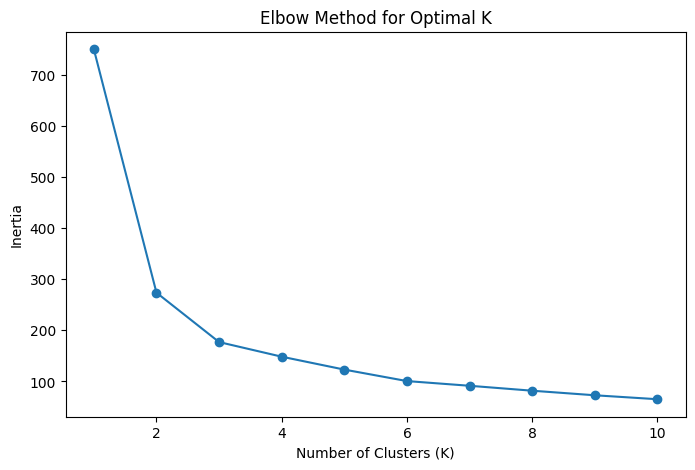


Cluster Distribution:
Cluster
1    53
2    50
0    47
Name: count, dtype: int64

Clustered Dataset:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
0,1,5.1,3.5,1.4,0.2,Iris-setosa,2
1,2,4.9,3.0,1.4,0.2,Iris-setosa,2
2,3,4.7,3.2,1.3,0.2,Iris-setosa,2
3,4,4.6,3.1,1.5,0.2,Iris-setosa,2
4,5,5.0,3.6,1.4,0.2,Iris-setosa,2
5,6,5.4,3.9,1.7,0.4,Iris-setosa,2
6,7,4.6,3.4,1.4,0.3,Iris-setosa,2
7,8,5.0,3.4,1.5,0.2,Iris-setosa,2
8,9,4.4,2.9,1.4,0.2,Iris-setosa,2
9,10,4.9,3.1,1.5,0.1,Iris-setosa,2


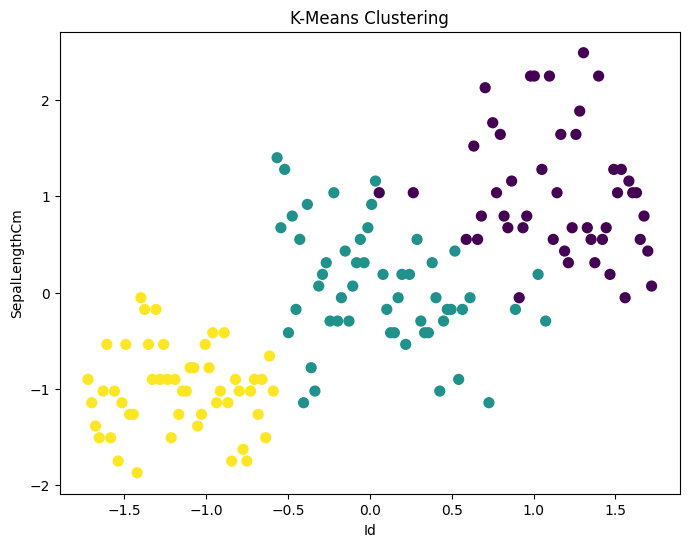


Cluster Centers:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,125.000000,6.697872,3.023404,5.591489,2.029787
1,78.773585,5.875472,2.737736,4.298113,1.362264
2,25.500000,5.006000,3.418000,1.464000,0.244000



✅ K-Means clustering completed successfully!
✅ Output saved as: kmeans_clustered_dataset.csv


In [2]:
# ============================================================
# K-MEANS CLUSTERING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ------------------------------------------------------------
# 1. Upload Dataset
# ------------------------------------------------------------

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

display(df.head())

# ------------------------------------------------------------
# 2. Select Numerical Features
# ------------------------------------------------------------

X = df.select_dtypes(include=np.number)

# Remove ID column if present
X = X.drop(columns=["StudentID"], errors="ignore")

print("\nFeatures used:")
print(X.columns.tolist())

# ------------------------------------------------------------
# 3. Handle Missing Values
# ------------------------------------------------------------

X = X.fillna(X.mean())

# ------------------------------------------------------------
# 4. Standardization
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# 5. Elbow Method
# ------------------------------------------------------------

inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Plot Elbow Curve

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

# ------------------------------------------------------------
# 6. Apply K-Means
# ------------------------------------------------------------

# Change this according to your elbow graph
k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels

df["Cluster"] = clusters

# ------------------------------------------------------------
# 7. Cluster Distribution
# ------------------------------------------------------------

print("\nCluster Distribution:")
print(df["Cluster"].value_counts())

# ------------------------------------------------------------
# 8. Display Clustered Dataset
# ------------------------------------------------------------

print("\nClustered Dataset:")

display(df.head(10))

# ------------------------------------------------------------
# 9. Visualize Clusters
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("K-Means Clustering")

plt.show()

# ------------------------------------------------------------
# 10. Cluster Centers
# ------------------------------------------------------------

centers = kmeans.cluster_centers_

centers_original = scaler.inverse_transform(centers)

centers_df = pd.DataFrame(
    centers_original,
    columns=X.columns
)

print("\nCluster Centers:")

display(centers_df)

# ------------------------------------------------------------
# 11. Save Result
# ------------------------------------------------------------

df.to_csv(
    "kmeans_clustered_dataset.csv",
    index=False
)

print("\n✅ K-Means clustering completed successfully!")
print("✅ Output saved as: kmeans_clustered_dataset.csv")